## 드라이브 연결

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 라이브러리 및 경로 설정

In [2]:
import os
import json
import random
import unicodedata
import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader, Subset
import torch.optim as optim

import torchvision
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from sklearn.model_selection import train_test_split

!pip install -q pycocotools
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

In [3]:
def normalize_path(path):
    return unicodedata.normalize("NFC", path).strip()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

BASE_DIR = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset")

TRAIN_JSON_PATH = os.path.join(BASE_DIR, "merged_annotations_train_final.json")
TEST_JSON_PATH  = os.path.join(BASE_DIR, "merged_annotations_test_final.json")
TRAIN_IMG_DIR   = os.path.join(BASE_DIR, "train_images")
TEST_IMG_DIR    = os.path.join(BASE_DIR, "test_images")

MODEL_SAVE_PATH = os.path.join(BASE_DIR, "faster_rcnn_best.pth")
SUBMISSION_PATH = os.path.join(BASE_DIR, "final_submission.csv")

print(TRAIN_JSON_PATH)
print(TEST_JSON_PATH)
print(TRAIN_IMG_DIR)
print(TEST_IMG_DIR)

DEVICE: cuda
/content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_train_final.json
/content/drive/MyDrive/data/초급_프로젝트/dataset/merged_annotations_test_final.json
/content/drive/MyDrive/data/초급_프로젝트/dataset/train_images
/content/drive/MyDrive/data/초급_프로젝트/dataset/test_images


## 학습 JSON을 DF로 변환

In [4]:
def build_df_from_merged_json(json_path, img_dir):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # image id -> file_name 매핑
    id_to_fname = {img["id"]: img["file_name"] for img in data["images"]}

    records = []
    for ann in data["annotations"]:
        coco_img_id = ann["image_id"]
        file_name = id_to_fname.get(coco_img_id)

        if file_name is None:
            continue

        img_path = os.path.join(img_dir, file_name)
        if not os.path.exists(img_path):
            continue

        x, y, w, h = ann["bbox"]

        records.append({
            "annotation_id": ann.get("id", -1),
            "image_id": os.path.splitext(file_name)[0],   # 파일명(확장자 제거)을 image_id로 사용
            "file_name": file_name,
            "image_path": img_path,
            "category_id": int(ann["category_id"]),       # 원본 category_id
            "bbox_x": float(x),
            "bbox_y": float(y),
            "bbox_w": float(w),
            "bbox_h": float(h),
            "score": 1.0                                  # train 정답에는 score 의미 없어서 1.0 고정
        })

    return pd.DataFrame(records)

df = build_df_from_merged_json(TRAIN_JSON_PATH, TRAIN_IMG_DIR)
print("학습 데이터 개수:", len(df))
print(df.head())

학습 데이터 개수: 4526
   annotation_id                                          image_id  \
0              1  K-001900-016551-024850-027926_0_2_0_2_90_000_200   
1              2  K-001900-016551-024850-027926_0_2_0_2_70_000_200   
2              3  K-001900-016551-024850-027926_0_2_0_2_75_000_200   
3              6  K-001900-016551-024850-027926_0_2_0_2_70_000_200   
4              7  K-001900-016551-024850-027926_0_2_0_2_70_000_200   

                                           file_name  \
0  K-001900-016551-024850-027926_0_2_0_2_90_000_2...   
1  K-001900-016551-024850-027926_0_2_0_2_70_000_2...   
2  K-001900-016551-024850-027926_0_2_0_2_75_000_2...   
3  K-001900-016551-024850-027926_0_2_0_2_70_000_2...   
4  K-001900-016551-024850-027926_0_2_0_2_70_000_2...   

                                          image_path  category_id  bbox_x  \
0  /content/drive/MyDrive/data/초급_프로젝트/dataset/tr...         1899   158.0   
1  /content/drive/MyDrive/data/초급_프로젝트/dataset/tr...         1899   631.

## category_id 매핑

In [5]:
unique_cats = sorted(df["category_id"].unique())
print("고유 category_id 개수:", len(unique_cats))

# 원본 category_id -> 모델 내부 label
# 모델 내부에서는 0이 background라서 실제 클래스는 1부터 시작
orig2model = {cid: i + 1 for i, cid in enumerate(unique_cats)}
model2orig = {v: k for k, v in orig2model.items()}

num_classes = len(unique_cats) + 1  # background 포함
print("num_classes:", num_classes)

고유 category_id 개수: 73
num_classes: 74


## transform

In [6]:
def get_train_transform():
    return T.Compose([
        T.ToTensor(),
    ])

def get_valid_transform():
    return T.Compose([
        T.ToTensor(),
    ])

## Dataset 정의

In [7]:
class OralDrugDataset(Dataset):
    def __init__(self, df, orig2model, transforms=None):
        self.df = df.reset_index(drop=True)
        self.orig2model = orig2model
        self.transforms = transforms
        self.image_ids = self.df["image_id"].unique().tolist()

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        df_img = self.df[self.df["image_id"] == image_id]

        img_path = df_img["image_path"].iloc[0]
        image = Image.open(img_path).convert("RGB")

        boxes = []
        labels = []
        areas = []

        for _, row in df_img.iterrows():
            x = row["bbox_x"]
            y = row["bbox_y"]
            w = row["bbox_w"]
            h = row["bbox_h"]

            x1 = x
            y1 = y
            x2 = x + w
            y2 = y + h

            if x2 <= x1 or y2 <= y1:
                continue

            boxes.append([x1, y1, x2, y2])

            # 원본 category_id -> 모델 내부 label
            orig_cat = int(row["category_id"])
            model_cat = self.orig2model[orig_cat]
            labels.append(model_cat)

            areas.append(w * h)

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)
        areas = torch.tensor(areas, dtype=torch.float32)
        iscrowd = torch.zeros((len(boxes),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx], dtype=torch.int64),
            "area": areas,
            "iscrowd": iscrowd
        }

        if self.transforms is not None:
            image = self.transforms(image)

        return image, target

## train / val 분리

In [8]:
image_ids = df["image_id"].unique().tolist()

train_ids, val_ids = train_test_split(
    image_ids,
    test_size=0.1,
    random_state=SEED,
    shuffle=True
)

train_df = df[df["image_id"].isin(train_ids)].reset_index(drop=True)
val_df   = df[df["image_id"].isin(val_ids)].reset_index(drop=True)

print("train image 수:", len(train_ids))
print("val image 수:", len(val_ids))

train image 수: 1340
val image 수: 149


## DataLoader

In [9]:
train_dataset = OralDrugDataset(
    train_df,
    orig2model=orig2model,
    transforms=get_train_transform()
)

val_dataset = OralDrugDataset(
    val_df,
    orig2model=orig2model,
    transforms=get_valid_transform()
)

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

print("train steps:", len(train_loader))
print("val steps:", len(val_loader))

train steps: 670
val steps: 75


## 모델 정의

In [10]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

model.to(DEVICE)
print("모델 준비 완료")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 218MB/s] 


모델 준비 완료


## optimizer / scheduler

In [11]:
params = [p for p in model.parameters() if p.requires_grad]

optimizer = optim.AdamW(params, lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

## 학습/검증 함수 정의

In [12]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0

    for images, targets in loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    return total_loss / len(loader)

In [13]:
def valid_one_epoch(model, loader, device):
    model.train()  # detection 모델은 eval에서 loss 반환 안 하는 경우가 많음
    total_loss = 0.0

    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            total_loss += losses.item()

    return total_loss / len(loader)

## 학습

In [23]:
num_epochs = 20
best_val_loss = float("inf")
history = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, DEVICE)
    val_loss = valid_one_epoch(model, val_loader, DEVICE)

    scheduler.step()

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    print(f"[Epoch {epoch+1}/{num_epochs}] train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    if val_loss < best_val_loss: 
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print("best model 저장 완료")

[Epoch 1/20] train_loss=0.1876 | val_loss=0.0851
best model 저장 완료
[Epoch 2/20] train_loss=0.1795 | val_loss=0.0649
best model 저장 완료
[Epoch 3/20] train_loss=0.1697 | val_loss=0.0646
best model 저장 완료
[Epoch 4/20] train_loss=0.1664 | val_loss=0.0633
best model 저장 완료
[Epoch 5/20] train_loss=0.1750 | val_loss=0.0637
[Epoch 6/20] train_loss=0.1686 | val_loss=0.0639
[Epoch 7/20] train_loss=0.1695 | val_loss=0.0639
[Epoch 8/20] train_loss=0.1589 | val_loss=0.0650
[Epoch 9/20] train_loss=0.1685 | val_loss=0.0634
[Epoch 10/20] train_loss=0.1673 | val_loss=0.0636
[Epoch 11/20] train_loss=0.1640 | val_loss=0.0646
[Epoch 12/20] train_loss=0.1655 | val_loss=0.0635
[Epoch 13/20] train_loss=0.1657 | val_loss=0.0639
[Epoch 14/20] train_loss=0.1650 | val_loss=0.0636
[Epoch 15/20] train_loss=0.1627 | val_loss=0.0652
[Epoch 16/20] train_loss=0.1685 | val_loss=0.0644
[Epoch 17/20] train_loss=0.1693 | val_loss=0.0649
[Epoch 18/20] train_loss=0.1669 | val_loss=0.0632
best model 저장 완료
[Epoch 19/20] train_loss

## best 모델 로드

In [24]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()
print("best model 로드 완료")

best model 로드 완료


## 검증 이미지 예측 확인

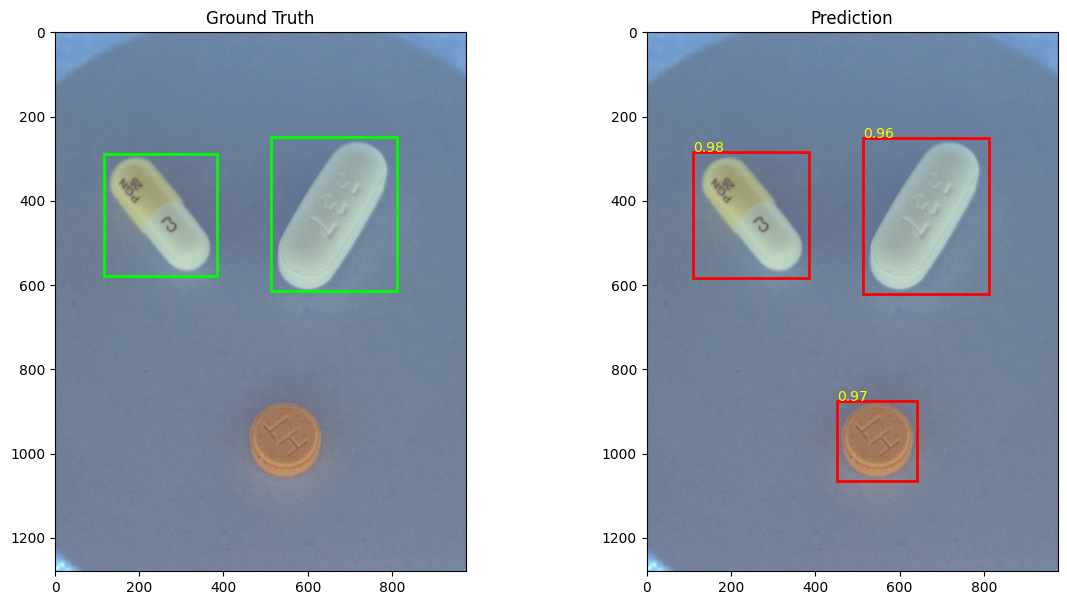

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_prediction(dataset, idx=0, score_threshold=0.3):
    image, target = dataset[idx]
    img_tensor = image.to(DEVICE)

    with torch.no_grad():
        output = model([img_tensor])[0]

    img_np = image.permute(1, 2, 0).cpu().numpy()

    fig, ax = plt.subplots(1, 2, figsize=(14, 7))

    # 정답
    ax[0].imshow(img_np)
    ax[0].set_title("Ground Truth")
    for box in target["boxes"]:
        x1, y1, x2, y2 = box.tolist()
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor="lime", facecolor="none"
        )
        ax[0].add_patch(rect)

    # 예측
    ax[1].imshow(img_np)
    ax[1].set_title("Prediction")
    boxes = output["boxes"].cpu().numpy()
    scores = output["scores"].cpu().numpy()

    for box, score in zip(boxes, scores):
        if score < score_threshold:
            continue
        x1, y1, x2, y2 = box
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor="red", facecolor="none"
        )
        ax[1].add_patch(rect)
        ax[1].text(x1, y1, f"{score:.2f}", color="yellow", fontsize=10)

    plt.show()

show_prediction(val_dataset, idx=0, score_threshold=0.3)

## 테스트 이미지 예측 후 submission.csv 생성

In [26]:
test_files = sorted([f for f in os.listdir(TEST_IMG_DIR) if f.endswith(".png")])

rows = []
score_threshold = 0.3

model.eval()

with torch.no_grad():
    for i, f in enumerate(test_files):
        img_path = os.path.join(TEST_IMG_DIR, f)
        image = Image.open(img_path).convert("RGB")

        image_id = os.path.splitext(f)[0]   # 예: 576.png -> 576

        img_tensor = T.ToTensor()(image).to(DEVICE)
        outputs = model([img_tensor])[0]

        keep = outputs["scores"].cpu() >= score_threshold
        boxes  = outputs["boxes"].cpu()[keep]
        labels = outputs["labels"].cpu()[keep]
        scores = outputs["scores"].cpu()[keep]

        for box, lab, sc in zip(boxes, labels, scores):
            x1, y1, x2, y2 = box.tolist()
            w = x2 - x1
            h = y2 - y1

            orig_cat = model2orig[int(lab.item())]

            rows.append({
                "image_id": image_id,
                "category_id": orig_cat + 1,   # 제출용 +1
                "bbox_x": x1,
                "bbox_y": y1,
                "bbox_w": w,
                "bbox_h": h,
                "score": float(sc.item())
            })

df_sub = pd.DataFrame(rows)

# 이미지별 score 높은 순으로 정렬 후 최대 4개만 남김
df_sub = df_sub.sort_values(by=["image_id", "score"], ascending=[True, False])
df_sub = df_sub.groupby("image_id").head(4).reset_index(drop=True)

# annotation_id 새로 부여
df_sub.insert(0, "annotation_id", range(1, len(df_sub) + 1))

# 컬럼 순서 맞추기
df_sub = df_sub[[
    "annotation_id",
    "image_id",
    "category_id",
    "bbox_x",
    "bbox_y",
    "bbox_w",
    "bbox_h",
    "score"
]]

df_sub.to_csv(SUBMISSION_PATH, index=False)

print("submission 저장 완료:", SUBMISSION_PATH)
print(df_sub.head())
print("총 예측 객체 수:", len(df_sub))

submission 저장 완료: /content/drive/MyDrive/data/초급_프로젝트/dataset/final_submission.csv
   annotation_id image_id  category_id      bbox_x      bbox_y      bbox_w  \
0              1        1         1900  158.403427  251.010956  201.517166   
1              2        1        27926  600.940247  673.140198  256.986206   
2              3        1        16551  556.333191   74.445900  403.172485   
3              4        1        24850  170.322876  735.759399  180.199585   
4              5       10         1900  640.991943  845.049133  189.922913   

       bbox_h     score  
0  125.242584  0.982645  
1  481.740784  0.977567  
2  398.277763  0.974751  
3  299.949951  0.909533  
4  188.586121  0.980804  
총 예측 객체 수: 3246


## sample submission 형식 확인

In [27]:
sample_sub = pd.read_csv(os.path.join(BASE_DIR, "final_solution.csv"))
print(sample_sub.head())
print(sample_sub.columns.tolist())

   annotation_id  image_id  num_objects  category_id  bbox_x  bbox_y  bbox_w  \
0              1         1            4         1900     158     251     202   
1              3         3            4         1900     143     242     200   
2             10         1            4        24850     173     740     180   
3             11         3            4        24850     141     701     180   
4             16         5            4         1900     181     267     131   

   bbox_h    Usage  
0     127   Public  
1     128  Private  
2     291   Public  
3     298  Private  
4     201   Public  
['annotation_id', 'image_id', 'num_objects', 'category_id', 'bbox_x', 'bbox_y', 'bbox_w', 'bbox_h', 'Usage']


## 학습 로그 확인

    epoch  train_loss  val_loss
0       1    0.187618  0.085113
1       2    0.179493  0.064929
2       3    0.169746  0.064643
3       4    0.166398  0.063291
4       5    0.174984  0.063686
5       6    0.168557  0.063947
6       7    0.169471  0.063870
7       8    0.158907  0.065021
8       9    0.168491  0.063434
9      10    0.167301  0.063615
10     11    0.164014  0.064608
11     12    0.165476  0.063522
12     13    0.165688  0.063858
13     14    0.164997  0.063559
14     15    0.162677  0.065154
15     16    0.168463  0.064395
16     17    0.169286  0.064869
17     18    0.166882  0.063232
18     19    0.170524  0.063171
19     20    0.169437  0.065870


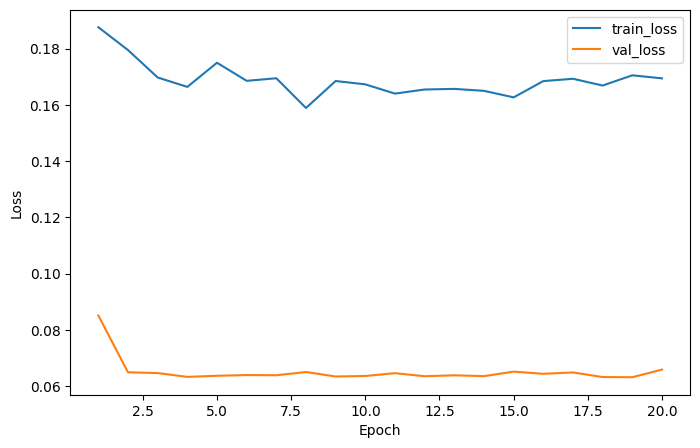

In [28]:
import matplotlib.pyplot as plt

hist_df = pd.DataFrame(history)
print(hist_df)
plt.figure(figsize=(8, 5))
plt.plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
plt.plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()